## CHALLENGE 3 : LM Survival Sentinel
In this challenge, participants will build machine learning models to predict whether a person affected by breast cancer is likely to survive. The models will be trained on patient data and outcomes, with the goal of providing insights into survival rates based on various health indicators.


In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.model_selection import RandomizedSearchCV 
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

## charger les donnes



In [134]:
df3 = pd.read_excel('train.xlsx')
df3.columns

Index(['Patient_ID', 'Age', 'Marital_Status', 'Year of Operation',
       'Positive_Axillary_Nodes', 'Tumor_Size', 'Radiation_Therapy',
       'Chemotherapy', 'Hormone_Therapy', 'Survival_Status'],
      dtype='object')

## Vérification détaillée des données

In [135]:
nul_columns = df3.isnull().sum()
nul_columns = nul_columns[nul_columns > 0]

print(nul_columns)

df3.describe().T

Series([], dtype: int64)


,count,mean,std,min,25%,50%,75%,max
Patient_ID,1500.0,750.500000,433.157015,1.0,375.75,750.5,1125.25,1500.0
Age,1500.0,56.894000,15.435768,30.0,44.00,57.0,70.00,83.0
Year of Operation,1500.0,1963.464667,3.382166,1958.0,1961.00,1963.0,1966.00,1969.0
Positive_Axillary_Nodes,1500.0,9.760000,10.324540,0.0,3.00,7.0,13.00,52.0
Tumor_Size,1500.0,2.785800,1.323994,0.5,1.70,2.8,3.90,5.0
Survival_Status,1500.0,0.493333,0.500122,0.0,0.00,0.0,1.00,1.0


## ya aucun element nul
# verifie le type de certain labels

In [136]:
print(df3['Radiation_Therapy'].unique())
print(df3['Marital_Status'].unique())
print(df3['Chemotherapy'].unique())
print(df3['Hormone_Therapy'].unique())

['No' 'Yes']
['Married' 'Single']
['Yes' 'No']
['No' 'Yes']


## une normalisation est necessaire pour  'Radiation_Therapy', 'Chemotherapy', 'Hormone_Therapy'

le rest pareille no need ya pas de difference qui peut cree un probleme au model

In [137]:
mapped_colomns = ['Radiation_Therapy', 'Chemotherapy', 'Hormone_Therapy']
df4 = df3
for col in mapped_colomns:
    df4[col] = df3[col].map({'No': 0, 'Yes': 1})

df4['Marital_Status'] = df3['Marital_Status'].map({'Single': 0, 'Married': 1})
print(df4['Chemotherapy'])

0       1
1       0
2       0
3       0
4       1
       ..
1495    1
1496    0
1497    0
1498    0
1499    0
Name: Chemotherapy, Length: 1500, dtype: int64


## visualitation des donnees a travers une matrice de  correlation entre les labels

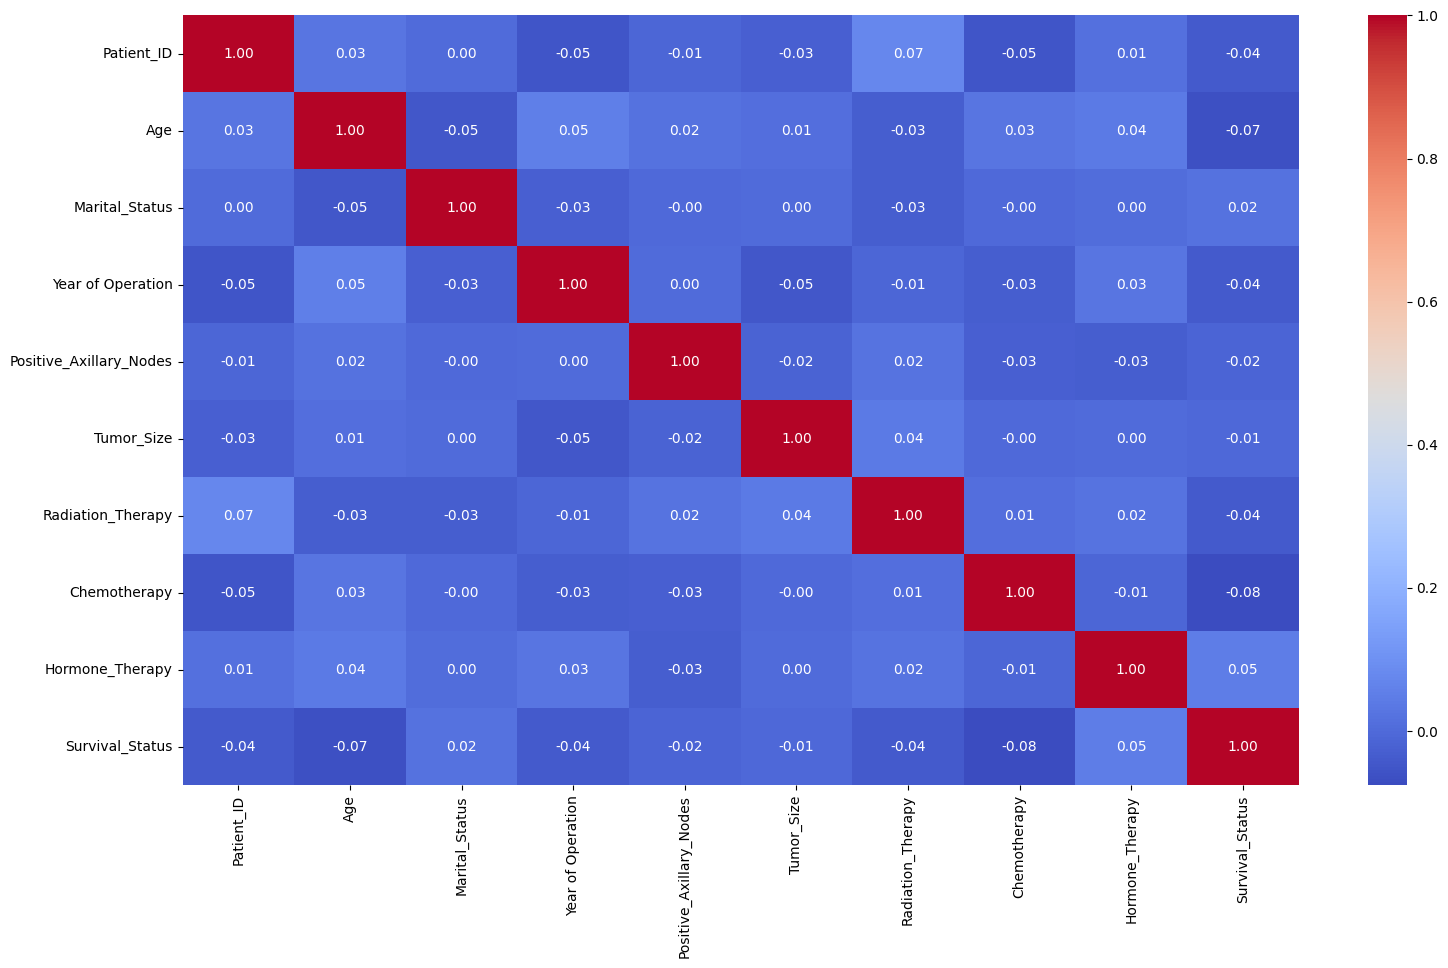

In [138]:
corr = df4.corr()
corrm = pd.DataFrame(corr)
plt.figure(figsize=(18, 10))
sns.heatmap(corrm, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

d'apres la correlation les colomns n'ont pas une relation lineare avec le label sible etant donner que ces une data de survis ces logique la mort est generalement aleatoir (el maktoub) alors en devrais garder toute les colonms

In [139]:
import statsmodels.api as sm
last = [ 'Age','Positive_Axillary_Nodes', 'Tumor_Size', 'Radiation_Therapy',
       'Chemotherapy', 'Hormone_Therapy']
X = df4[last]

X = sm.add_constant(X)

y = df4['Survival_Status']

logit_model = sm.Logit(y, X)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.685583
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        Survival_Status   No. Observations:                 1500
Model:                          Logit   Df Residuals:                     1493
Method:                           MLE   Df Model:                            6
Date:                Sat, 19 Oct 2024   Pseudo R-squ.:                 0.01079
Time:                        21:15:16   Log-Likelihood:                -1028.4
converged:                       True   LL-Null:                       -1039.6
Covariance Type:            nonrobust   LLR p-value:                  0.001013
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.7902      0.257      3.077      0.002       0.287   

j'ai tester une regression logique sur la data pour voir  une autre relation entre les colonms et survival status 

d'apres le p value ( P>|z|)  en peut voir que age et chemotherapy on une plus grande chance d'affecter le status de survis  meme si il rest mince donc rien a conclure

## on vas directement passer a l'entrainement

d'abord charger les donners du test et normaliser les strings en  binnair


In [141]:
X_test=pd.read_csv('test.csv')
for col in mapped_colomns:
    X_test[col] = X_test[col].map({'No': 0, 'Yes': 1})

X_test['Marital_Status'] = X_test['Marital_Status'].map({'Single': 0, 'Married': 1})



on devise les differant dataframe pour le train 

In [142]:
X_train= df4
X_train=X_train.drop('Survival_Status',axis=1)
y_train = df4['Survival_Status']

entrainement sur le model randome forest

In [144]:


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf_classifier = RandomForestClassifier(random_state=15)

param_grid = {
    'n_estimators': [100, 200,250],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(estimator=rf_classifier, 
                                   param_distributions=param_grid, 
                                   n_iter=100, cv=3, 
                                   random_state=42, n_jobs=-1)


random_search.fit(X_train, y_train)
print("Best Parameters:", random_search.best_params_)
y_pred_optimized = random_search.predict(X_test)
prediction = pd.read_csv('sample_submissions.csv')
prediction['Survival_Status'] = y_pred_optimized
prediction.to_csv('sample_submissions.csv', index=False)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}
